# 04 Error Analysis — total_time_min

วิเคราะห์เชิงลึกว่าโมเดล **XGBoost (Best)** ทำนายผิดพลาดที่ไหน อย่างไร และทำไม

- Error distribution overview
- Error by CarType / PickListType
- Error by Hour of Day & Month
- Error by SAP Volume (load size)
- Error Heatmap (Hour × CarType)
- Under-prediction vs Over-prediction patterns
- Worst predictions deep dive
- Summary & recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

MODEL_DIR  = Path('../../models')
FIGURE_DIR = Path('../../reports/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET       = 'total_time_min'
RANDOM_STATE = 42

# CarType mapping (encoded → label)
CARTYPE_MAP = {0: '4W', 1: '6W', 2: '10W', 3: 'Trailer'}
PICKLIST_MAP = {0: 'Normal', 1: 'Forward', 2: 'Return'}

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded ✓')

Libraries loaded ✓


## Load Data & Model

In [2]:
train_df = pd.read_csv('../../data/processed/train.csv', encoding='utf-8-sig')
test_df  = pd.read_csv('../../data/processed/test.csv',  encoding='utf-8-sig')

feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET]
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET]

non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    X_train = X_train.drop(columns=non_numeric)
    X_test  = X_test.drop(columns=non_numeric)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

best_model = joblib.load(MODEL_DIR / 'xgb_tuned_totaltime.joblib')

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Model loaded : XGBoost (Optuna)')

Train : (17668, 26)  |  Test : (4417, 26)
Model loaded : XGBoost (Optuna)


In [3]:
y_pred = best_model.predict(X_test)

err_df = test_df.copy()
err_df['predicted']  = y_pred
err_df['residual']   = err_df[TARGET] - err_df['predicted']
err_df['abs_error']  = err_df['residual'].abs()
err_df['pct_error']  = (err_df['abs_error'] / err_df[TARGET] * 100).round(2)
err_df['direction']  = np.where(err_df['residual'] > 0, 'Under-predict', 'Over-predict')

# Decode labels
err_df['CarType_lbl']    = err_df['CarType'].map(CARTYPE_MAP).fillna('Unknown')
err_df['PickList_lbl']   = err_df['PickListType'].map(PICKLIST_MAP).fillna('Unknown')

# SAP Volume buckets
err_df['sap_bucket'] = pd.cut(
    err_df['total_sap_amount'],
    bins=[0, 20, 50, 100, 200, np.inf],
    labels=['0-20', '20-50', '50-100', '100-200', '>200']
)

# Error buckets
err_df['err_bucket'] = pd.cut(
    err_df['abs_error'],
    bins=[0, 5, 10, 15, 30, np.inf],
    labels=['0-5 min', '5-10 min', '10-15 min', '15-30 min', '>30 min']
)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'Test samples : {len(err_df):,}')
print(f'MAE  = {mae:.2f} min')
print(f'RMSE = {rmse:.2f} min')
print(f'R²   = {r2:.3f}')
print(f'\nResidual mean : {err_df["residual"].mean():.4f} min  (bias)')
print(f'Residual std  : {err_df["residual"].std():.4f} min')

Test samples : 4,417
MAE  = 11.43 min
RMSE = 14.47 min
R²   = 0.555

Residual mean : -1.7641 min  (bias)
Residual std  : 14.3594 min


## 1. Overall Error Distribution

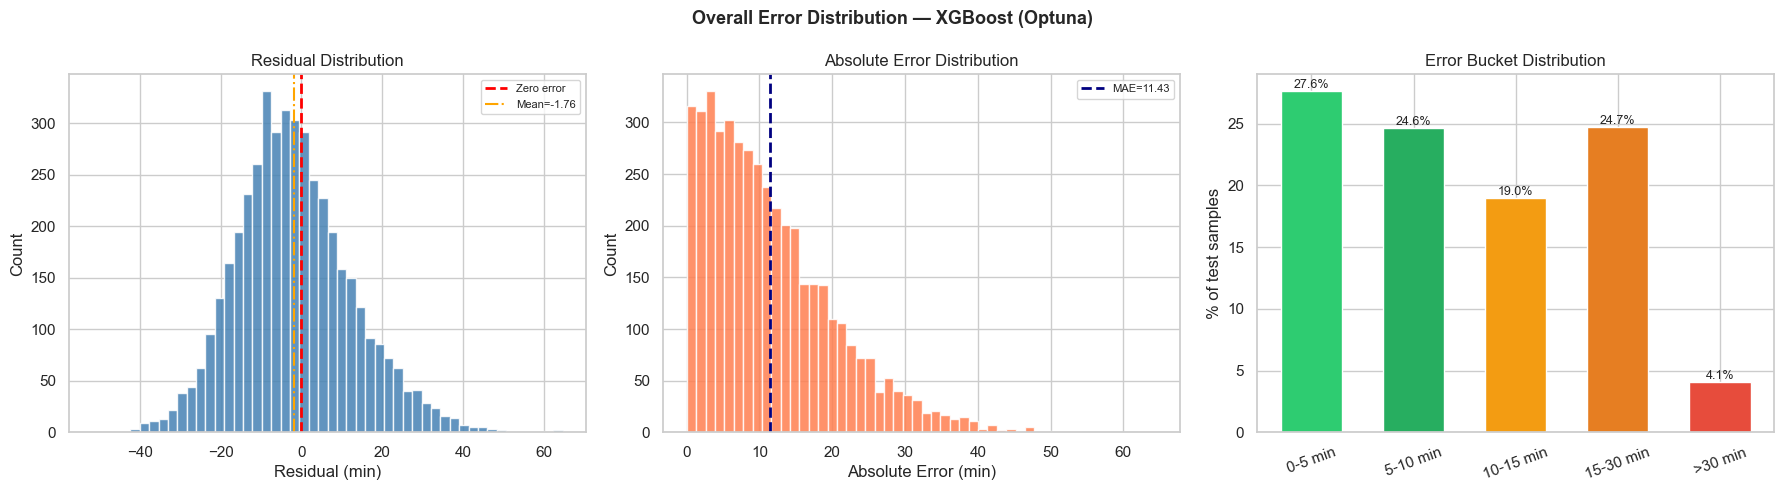

Error bucket summary:
  0-5 min     : 1221 ( 27.6%)  #############
  5-10 min    : 1086 ( 24.6%)  ############
  10-15 min   :  838 ( 19.0%)  #########
  15-30 min   : 1091 ( 24.7%)  ############
  >30 min     :  181 (  4.1%)  ##

Error <=10 min : 52.2%
Error <=15 min : 71.2%
Error  >30 min : 4.1%


In [4]:
bucket_labels = ['0-5 min', '5-10 min', '10-15 min', '15-30 min', '>30 min']
bucket_pct = err_df['err_bucket'].value_counts().reindex(bucket_labels)
bucket_pct_pct = (bucket_pct / len(err_df) * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Overall Error Distribution — XGBoost (Optuna)', fontsize=13, fontweight='bold')

# Residual histogram
ax = axes[0]
ax.hist(err_df['residual'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', lw=2, ls='--', label='Zero error')
ax.axvline(err_df['residual'].mean(), color='orange', lw=1.5, ls='-.', label=f'Mean={err_df["residual"].mean():.2f}')
ax.set_xlabel('Residual (min)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')
ax.legend(fontsize=8)

# Absolute error histogram
ax = axes[1]
ax.hist(err_df['abs_error'], bins=50, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(mae, color='navy', lw=2, ls='--', label=f'MAE={mae:.2f}')
ax.set_xlabel('Absolute Error (min)')
ax.set_ylabel('Count')
ax.set_title('Absolute Error Distribution')
ax.legend(fontsize=8)

# Error bucket bar
ax = axes[2]
colors_b = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(bucket_labels, bucket_pct_pct, color=colors_b, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)
ax.set_ylabel('% of test samples')
ax.set_title('Error Bucket Distribution')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_01_overall_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Error bucket summary:')
for lbl, cnt, pct in zip(bucket_labels, bucket_pct, bucket_pct_pct):
    bar = '#' * int(pct / 2)
    print(f'  {lbl:<12}: {cnt:>4} ({pct:>5.1f}%)  {bar}')
print(f'\nError <=10 min : {bucket_pct_pct.iloc[0] + bucket_pct_pct.iloc[1]:.1f}%')
print(f'Error <=15 min : {sum(bucket_pct_pct.iloc[:3]):.1f}%')
print(f'Error  >30 min : {bucket_pct_pct.iloc[4]:.1f}%')

## 2. Error by CarType

=== Error by CarType ===
             Count    MAE   RMSE  Median_AE  Mean_Actual  Bias  Pct_Within10  Pct_Over30
CarType_lbl                                                                             
10W            139  10.77  13.83       8.76        57.54  0.82         55.40        5.04
4W             294   8.79  11.18       7.67        35.25 -1.49         63.27        2.72
6W            2365  10.05  12.60       8.49        47.77 -1.83         57.80        1.73
Trailer       1619  13.98  17.31      12.28        70.49 -1.93         41.82        7.72


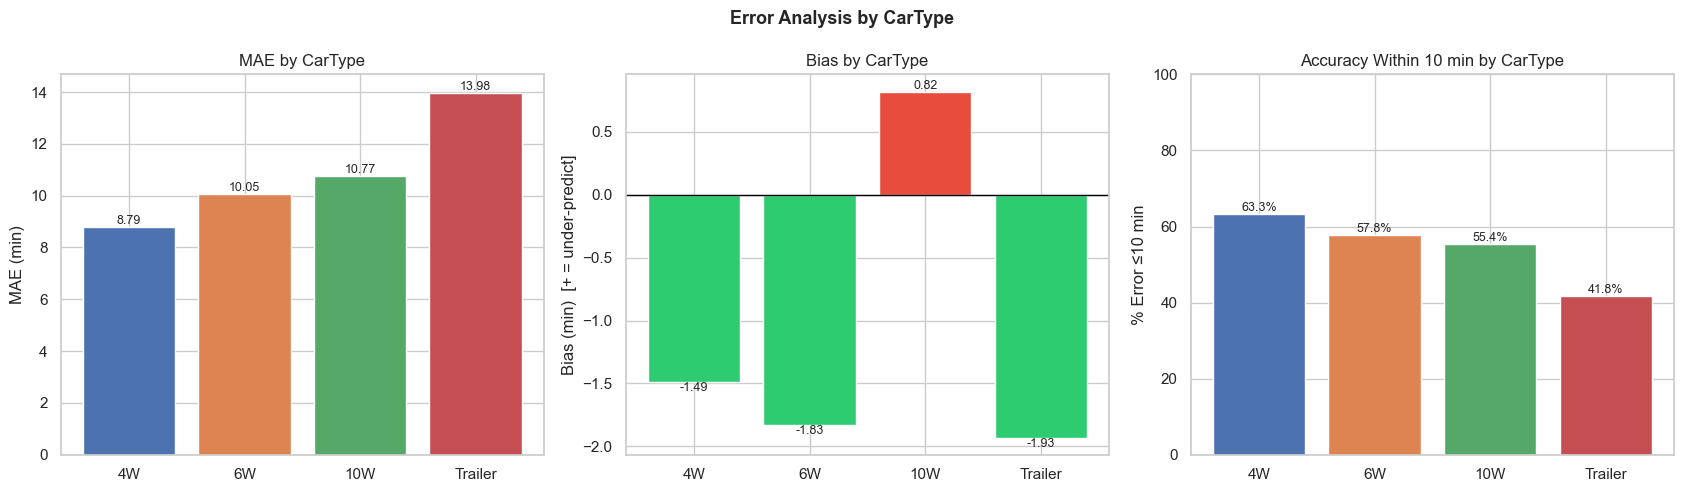

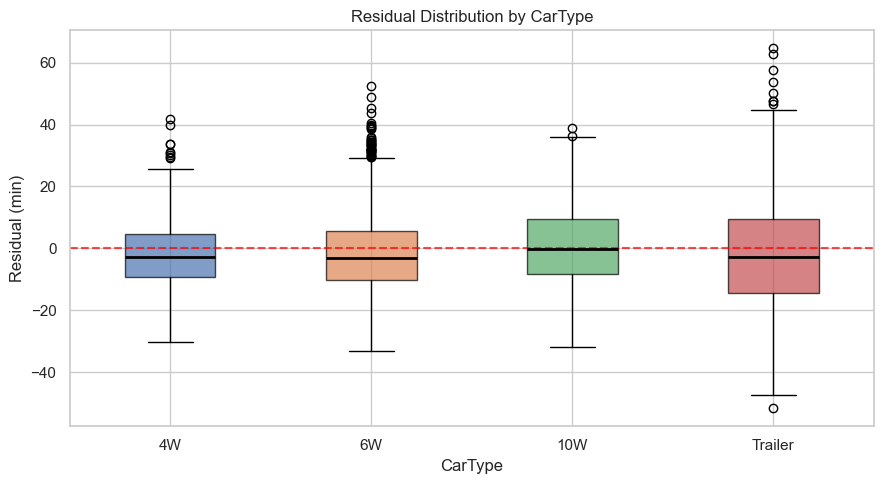

In [5]:
ct_stats = err_df.groupby('CarType_lbl').agg(
    Count       = ('abs_error', 'count'),
    MAE         = ('abs_error', 'mean'),
    RMSE        = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    Median_AE   = ('abs_error', 'median'),
    Mean_Actual = (TARGET, 'mean'),
    Bias        = ('residual', 'mean'),
    Pct_Within10 = ('abs_error', lambda x: (x <= 10).mean() * 100),
    Pct_Over30   = ('abs_error', lambda x: (x > 30).mean() * 100),
).round(2)

print('=== Error by CarType ===')
print(ct_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Error Analysis by CarType', fontsize=13, fontweight='bold')

ct_order = ['4W', '6W', '10W', 'Trailer']
ct_plot  = ct_stats.reindex(ct_order)
palette  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# MAE bar
ax = axes[0]
bars = ax.bar(ct_plot.index, ct_plot['MAE'], color=palette, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.set_ylabel('MAE (min)')
ax.set_title('MAE by CarType')

# Bias bar
ax = axes[1]
colors_bias = ['#e74c3c' if v > 0 else '#2ecc71' for v in ct_plot['Bias']]
bars = ax.bar(ct_plot.index, ct_plot['Bias'], color=colors_bias, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Bias (min)  [+ = under-predict]')
ax.set_title('Bias by CarType')

# % within 10 min
ax = axes[2]
bars = ax.bar(ct_plot.index, ct_plot['Pct_Within10'], color=palette, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)
ax.set_ylim(0, 100)
ax.set_ylabel('% Error ≤10 min')
ax.set_title('Accuracy Within 10 min by CarType')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_02_error_by_cartype.png', dpi=120, bbox_inches='tight')
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(9, 5))
groups = [err_df[err_df['CarType_lbl'] == ct]['residual'].dropna() for ct in ct_order]
bp = ax.boxplot(groups, labels=ct_order, patch_artist=True, notch=False,
               medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='red', lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('CarType')
ax.set_ylabel('Residual (min)')
ax.set_title('Residual Distribution by CarType')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_02b_residual_boxplot_cartype.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Error by PickListType

=== Error by PickListType ===
              Count    MAE   RMSE  Bias  Mean_Actual  Pct_Within10  Pct_Over30
PickList_lbl                                                                  
Forward         256  14.35  18.12 -3.14        70.17         42.97        9.77
Normal         2642  10.35  13.08 -1.65        50.14         56.81        2.76
Return         1519  12.80  15.99 -1.73        62.56         45.82        5.46


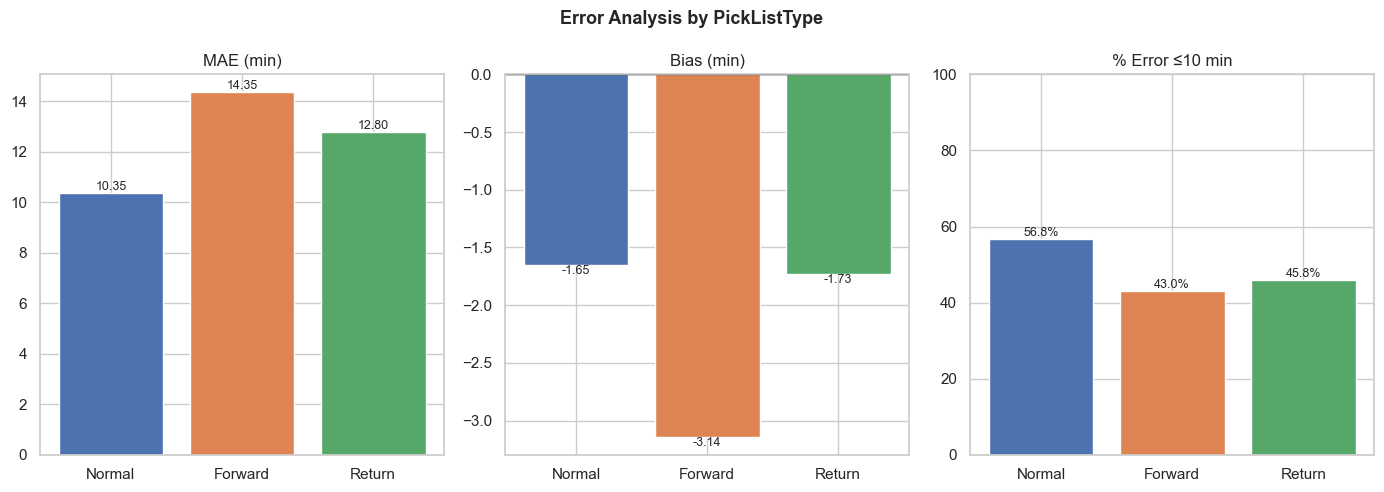

In [6]:
pl_stats = err_df.groupby('PickList_lbl').agg(
    Count        = ('abs_error', 'count'),
    MAE          = ('abs_error', 'mean'),
    RMSE         = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    Bias         = ('residual', 'mean'),
    Mean_Actual  = (TARGET, 'mean'),
    Pct_Within10 = ('abs_error', lambda x: (x <= 10).mean() * 100),
    Pct_Over30   = ('abs_error', lambda x: (x > 30).mean() * 100),
).round(2)

print('=== Error by PickListType ===')
print(pl_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Error Analysis by PickListType', fontsize=13, fontweight='bold')

palette_pl = ['#4C72B0', '#DD8452', '#55A868']
pl_order   = [p for p in ['Normal', 'Forward', 'Return'] if p in pl_stats.index]
pl_plot    = pl_stats.reindex(pl_order)

for ax, (col, title, fmt) in zip(axes, [
    ('MAE',  'MAE (min)', '%.2f'),
    ('Bias', 'Bias (min)', '%.2f'),
    ('Pct_Within10', '% Error ≤10 min', '%.1f%%'),
]):
    bars = ax.bar(pl_plot.index, pl_plot[col],
                  color=palette_pl[:len(pl_order)], edgecolor='white')
    ax.bar_label(bars, fmt=fmt, fontsize=9)
    ax.set_title(title)
    if 'Bias' in col:
        ax.axhline(0, color='black', lw=1)
    if 'Pct' in col:
        ax.set_ylim(0, 100)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_03_error_by_picklist.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Error by Hour of Day

=== Error by Hour ===
      Count    MAE  Bias  Pct_Within10  Pct_Over30  Mean_Actual
hour                                                           
7       614  10.67 -3.24         55.37        2.93        55.53
8       328  11.65 -1.86         51.83        6.71        52.90
9       372  11.94 -1.59         49.19        3.49        55.01
10      395  11.87 -2.96         48.35        3.80        52.70
11      379  11.19 -1.29         54.35        4.49        55.32
12      370  12.15 -1.88         50.81        4.32        56.88
13      450  12.04 -0.11         50.22        5.56        58.34
14      489  11.75 -2.74         49.28        3.07        53.96
15      448  10.49 -1.15         56.92        4.24        56.02
16      377  10.79 -0.47         57.29        3.45        57.59
17      147  11.64 -1.86         48.30        4.76        56.52
18       38  12.34  2.59         39.47        2.63        62.52
19       10  12.00  1.35         50.00        0.00        60.10


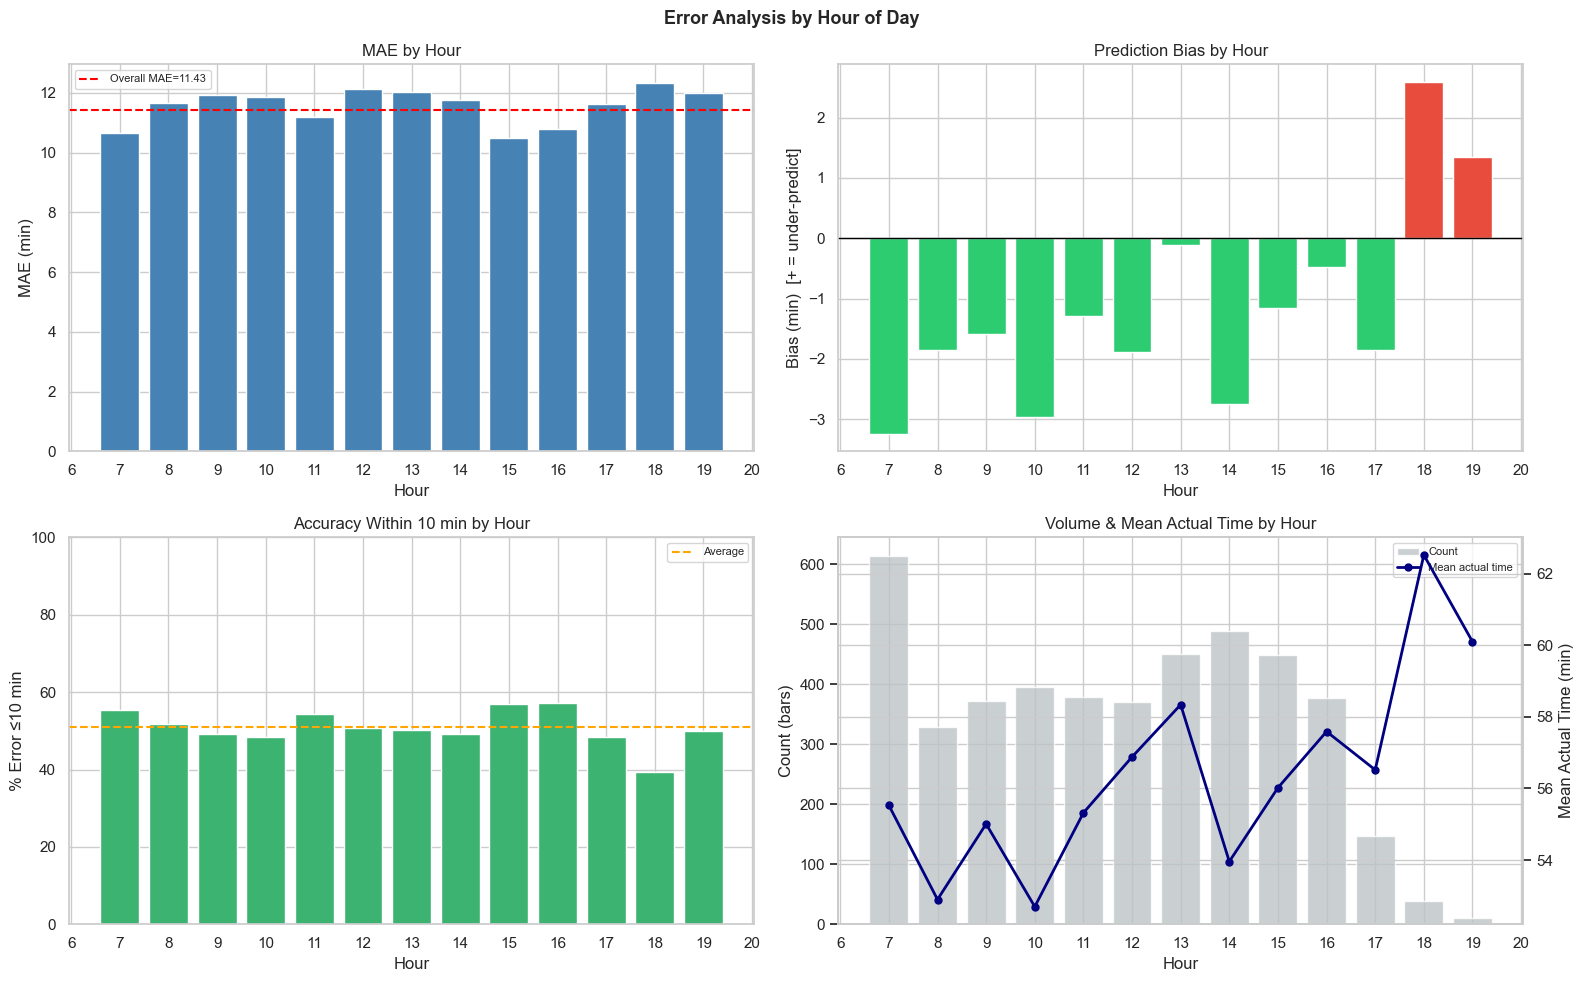

In [7]:
hr_stats = err_df.groupby('hour').agg(
    Count       = ('abs_error', 'count'),
    MAE         = ('abs_error', 'mean'),
    Bias        = ('residual', 'mean'),
    Pct_Within10= ('abs_error', lambda x: (x <= 10).mean() * 100),
    Pct_Over30  = ('abs_error', lambda x: (x > 30).mean() * 100),
    Mean_Actual = (TARGET, 'mean'),
).round(2)

print('=== Error by Hour ===')
print(hr_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Error Analysis by Hour of Day', fontsize=13, fontweight='bold')

hours = hr_stats.index

# MAE by hour
ax = axes[0][0]
ax.bar(hours, hr_stats['MAE'], color='steelblue', edgecolor='white')
ax.axhline(mae, color='red', lw=1.5, ls='--', label=f'Overall MAE={mae:.2f}')
ax.set_xlabel('Hour'); ax.set_ylabel('MAE (min)')
ax.set_title('MAE by Hour')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Bias by hour
ax = axes[0][1]
colors_hr = ['#e74c3c' if v > 0 else '#2ecc71' for v in hr_stats['Bias']]
ax.bar(hours, hr_stats['Bias'], color=colors_hr, edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Hour'); ax.set_ylabel('Bias (min)  [+ = under-predict]')
ax.set_title('Prediction Bias by Hour')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# % within 10 min
ax = axes[1][0]
ax.bar(hours, hr_stats['Pct_Within10'], color='mediumseagreen', edgecolor='white')
ax.axhline(hr_stats['Pct_Within10'].mean(), color='orange', lw=1.5, ls='--', label='Average')
ax.set_ylim(0, 100)
ax.set_xlabel('Hour'); ax.set_ylabel('% Error ≤10 min')
ax.set_title('Accuracy Within 10 min by Hour')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Count + Mean actual by hour
ax = axes[1][1]
ax2 = ax.twinx()
ax.bar(hours, hr_stats['Count'], color='#BDC3C7', edgecolor='white', alpha=0.8, label='Count')
ax2.plot(hours, hr_stats['Mean_Actual'], 'o-', color='navy', lw=2, ms=5, label='Mean actual time')
ax.set_xlabel('Hour')
ax.set_ylabel('Count (bars)')
ax2.set_ylabel('Mean Actual Time (min)')
ax.set_title('Volume & Mean Actual Time by Hour')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_04_error_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Error by Month

=== Error by Month ===
 month month_lbl  Count   MAE  RMSE  Bias  Pct_Within10  Pct_Over30
     2       Feb    734 11.17 14.29 -0.56         53.95        3.81
     3       Mar   1571 11.20 14.37 -0.22         55.32        4.26
     4       Apr   1347 11.80 14.76 -2.53         49.07        4.31
     5       May    765 11.50 14.31 -4.75         49.80        3.66


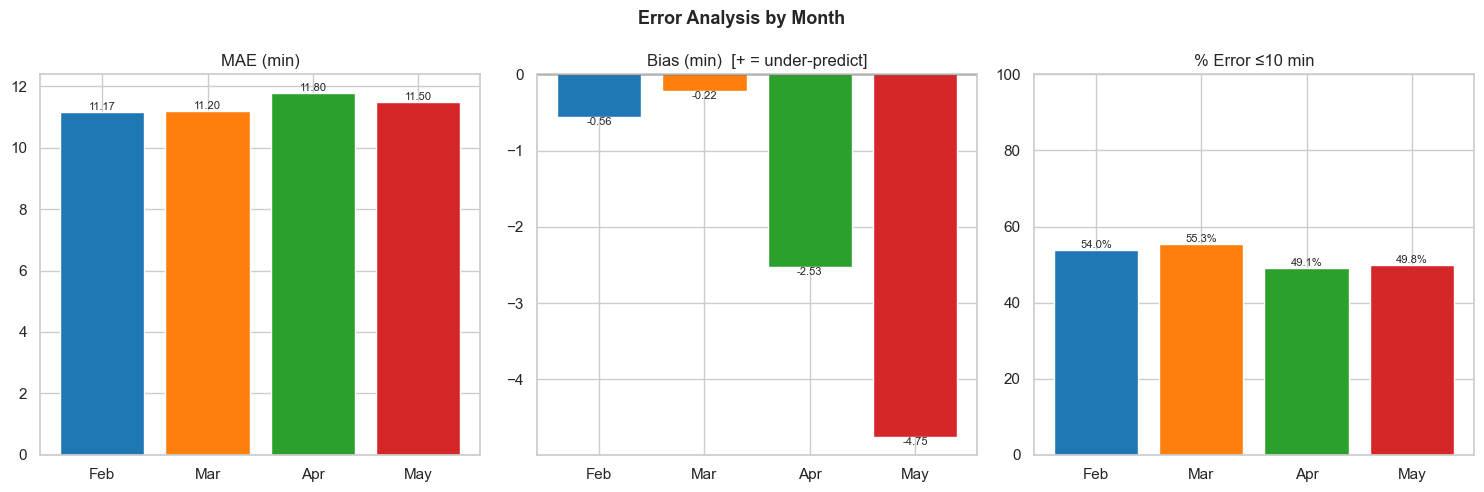

In [8]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
err_df['month_lbl'] = err_df['month'].map(month_map)

mo_stats = err_df.groupby(['month', 'month_lbl']).agg(
    Count       = ('abs_error', 'count'),
    MAE         = ('abs_error', 'mean'),
    RMSE        = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    Bias        = ('residual', 'mean'),
    Pct_Within10= ('abs_error', lambda x: (x <= 10).mean() * 100),
    Pct_Over30  = ('abs_error', lambda x: (x > 30).mean() * 100),
).round(2).reset_index().sort_values('month')

print('=== Error by Month ===')
print(mo_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Error Analysis by Month', fontsize=13, fontweight='bold')

palette_mo = sns.color_palette('tab10', len(mo_stats))

for ax, (col, title, fmt) in zip(axes, [
    ('MAE',  'MAE (min)', '%.2f'),
    ('Bias', 'Bias (min)  [+ = under-predict]', '%.2f'),
    ('Pct_Within10', '% Error ≤10 min', '%.1f%%'),
]):
    bars = ax.bar(mo_stats['month_lbl'], mo_stats[col],
                  color=palette_mo, edgecolor='white')
    ax.bar_label(bars, fmt=fmt, fontsize=8)
    ax.set_title(title)
    if 'Bias' in col:
        ax.axhline(0, color='black', lw=1)
    if 'Pct' in col:
        ax.set_ylim(0, 100)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_05_error_by_month.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Error by SAP Volume (Load Size)

=== Error by SAP Volume ===
            Count    MAE   RMSE  Bias  Mean_Actual  Pct_Within10  Pct_Over30
sap_bucket                                                                  
0-20           21  11.68  15.46  3.19        35.13         52.38        9.52
20-50          26  10.30  13.20 -0.25        32.34         50.00        3.85
50-100         28  10.93  17.67  2.92        39.16         67.86       10.71
100-200        66  11.10  14.34  0.59        40.61         54.55        3.03
>200         4276  11.44  14.45 -1.86        56.15         52.10        4.05


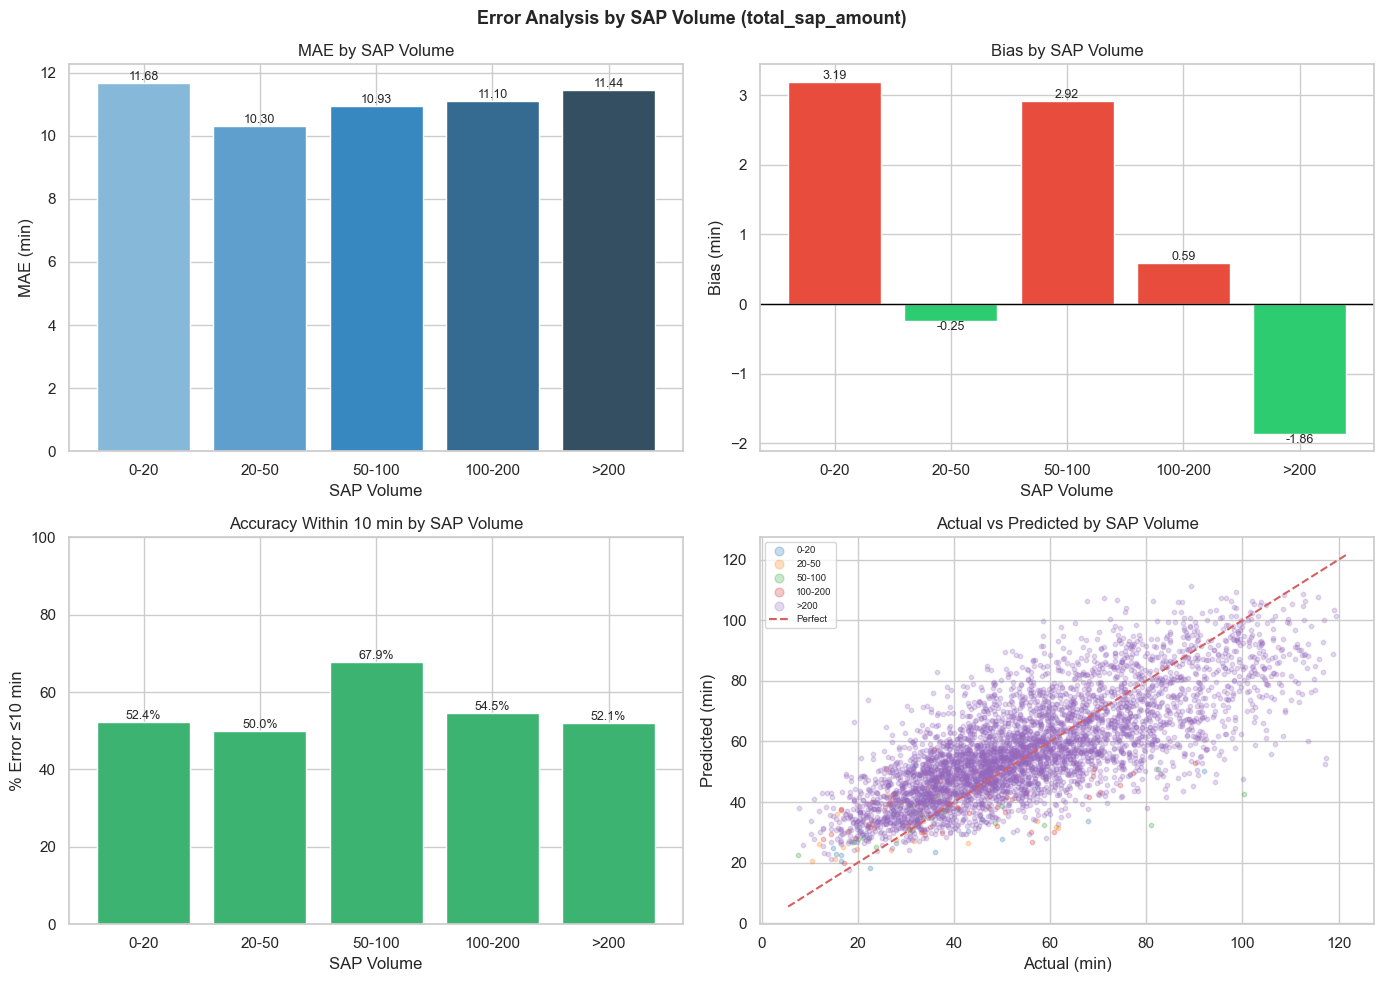

In [9]:
sap_stats = err_df.groupby('sap_bucket', observed=True).agg(
    Count       = ('abs_error', 'count'),
    MAE         = ('abs_error', 'mean'),
    RMSE        = ('abs_error', lambda x: np.sqrt((x**2).mean())),
    Bias        = ('residual', 'mean'),
    Mean_Actual = (TARGET, 'mean'),
    Pct_Within10= ('abs_error', lambda x: (x <= 10).mean() * 100),
    Pct_Over30  = ('abs_error', lambda x: (x > 30).mean() * 100),
).round(2)

print('=== Error by SAP Volume ===')
print(sap_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Error Analysis by SAP Volume (total_sap_amount)', fontsize=13, fontweight='bold')

sap_labels = sap_stats.index.tolist()
palette_sap = sns.color_palette('Blues_d', len(sap_labels))

# MAE
ax = axes[0][0]
bars = ax.bar(sap_labels, sap_stats['MAE'], color=palette_sap, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.set_xlabel('SAP Volume'); ax.set_ylabel('MAE (min)')
ax.set_title('MAE by SAP Volume')

# Bias
ax = axes[0][1]
colors_sap = ['#e74c3c' if v > 0 else '#2ecc71' for v in sap_stats['Bias']]
bars = ax.bar(sap_labels, sap_stats['Bias'], color=colors_sap, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('SAP Volume'); ax.set_ylabel('Bias (min)')
ax.set_title('Bias by SAP Volume')

# % within 10 min
ax = axes[1][0]
bars = ax.bar(sap_labels, sap_stats['Pct_Within10'], color='mediumseagreen', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)
ax.set_ylim(0, 100)
ax.set_xlabel('SAP Volume'); ax.set_ylabel('% Error ≤10 min')
ax.set_title('Accuracy Within 10 min by SAP Volume')

# Scatter: actual vs predicted colored by sap_bucket
ax = axes[1][1]
palette_scatter = sns.color_palette('tab10', len(sap_labels))
for color, bucket in zip(palette_scatter, sap_labels):
    mask = err_df['sap_bucket'] == bucket
    ax.scatter(err_df.loc[mask, TARGET], err_df.loc[mask, 'predicted'],
               alpha=0.25, s=10, color=color, label=bucket)
lim = [err_df[TARGET].min()-2, err_df[TARGET].max()+2]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual (min)'); ax.set_ylabel('Predicted (min)')
ax.set_title('Actual vs Predicted by SAP Volume')
ax.legend(fontsize=7, markerscale=2)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_06_error_by_sap_volume.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Error Heatmap — Hour × CarType

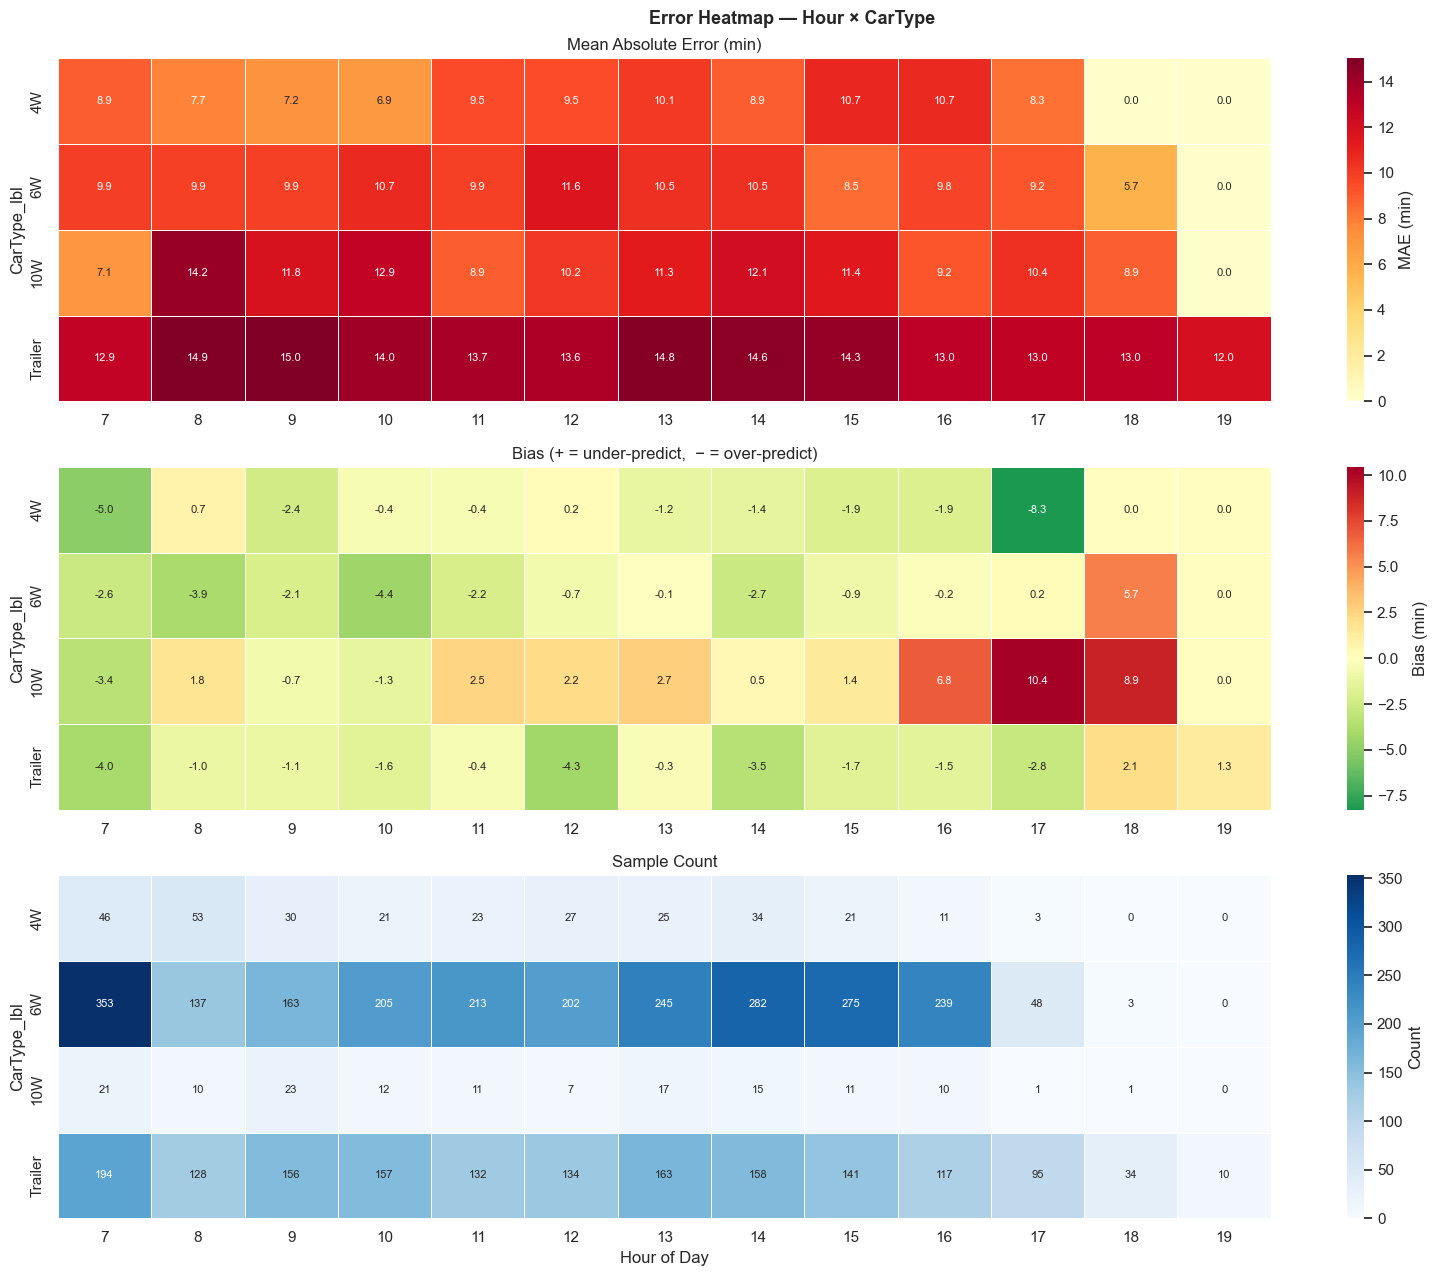

In [10]:
# MAE heatmap
hm_mae = err_df.pivot_table(
    index='CarType_lbl', columns='hour',
    values='abs_error', aggfunc='mean'
).reindex(['4W', '6W', '10W', 'Trailer'])

# Count heatmap
hm_cnt = err_df.pivot_table(
    index='CarType_lbl', columns='hour',
    values='abs_error', aggfunc='count'
).reindex(['4W', '6W', '10W', 'Trailer'])

# Bias heatmap
hm_bias = err_df.pivot_table(
    index='CarType_lbl', columns='hour',
    values='residual', aggfunc='mean'
).reindex(['4W', '6W', '10W', 'Trailer'])

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('Error Heatmap — Hour × CarType', fontsize=13, fontweight='bold')

kw = dict(linewidths=0.5, linecolor='white', fmt='.1f', annot=True, annot_kws={'size': 8})

sns.heatmap(hm_mae.fillna(0), ax=axes[0], cmap='YlOrRd',
            cbar_kws={'label': 'MAE (min)'}, **kw)
axes[0].set_title('Mean Absolute Error (min)')
axes[0].set_xlabel('')

sns.heatmap(hm_bias.fillna(0), ax=axes[1], cmap='RdYlGn_r',
            center=0, cbar_kws={'label': 'Bias (min)'}, **kw)
axes[1].set_title('Bias (+ = under-predict,  − = over-predict)')
axes[1].set_xlabel('')

sns.heatmap(hm_cnt.fillna(0).astype(int), ax=axes[2], cmap='Blues',
            cbar_kws={'label': 'Count'}, fmt='d', annot=True, annot_kws={'size': 8},
            linewidths=0.5, linecolor='white')
axes[2].set_title('Sample Count')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_07_heatmap_hour_cartype.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Under-prediction vs Over-prediction Analysis

Under-predict (actual > predicted) : 1,827  (41.4%)
Over-predict  (actual < predicted) : 2,590  (58.6%)

Under-predict — Mean error  : +11.68 min
Over-predict  — Mean error  : -11.25 min


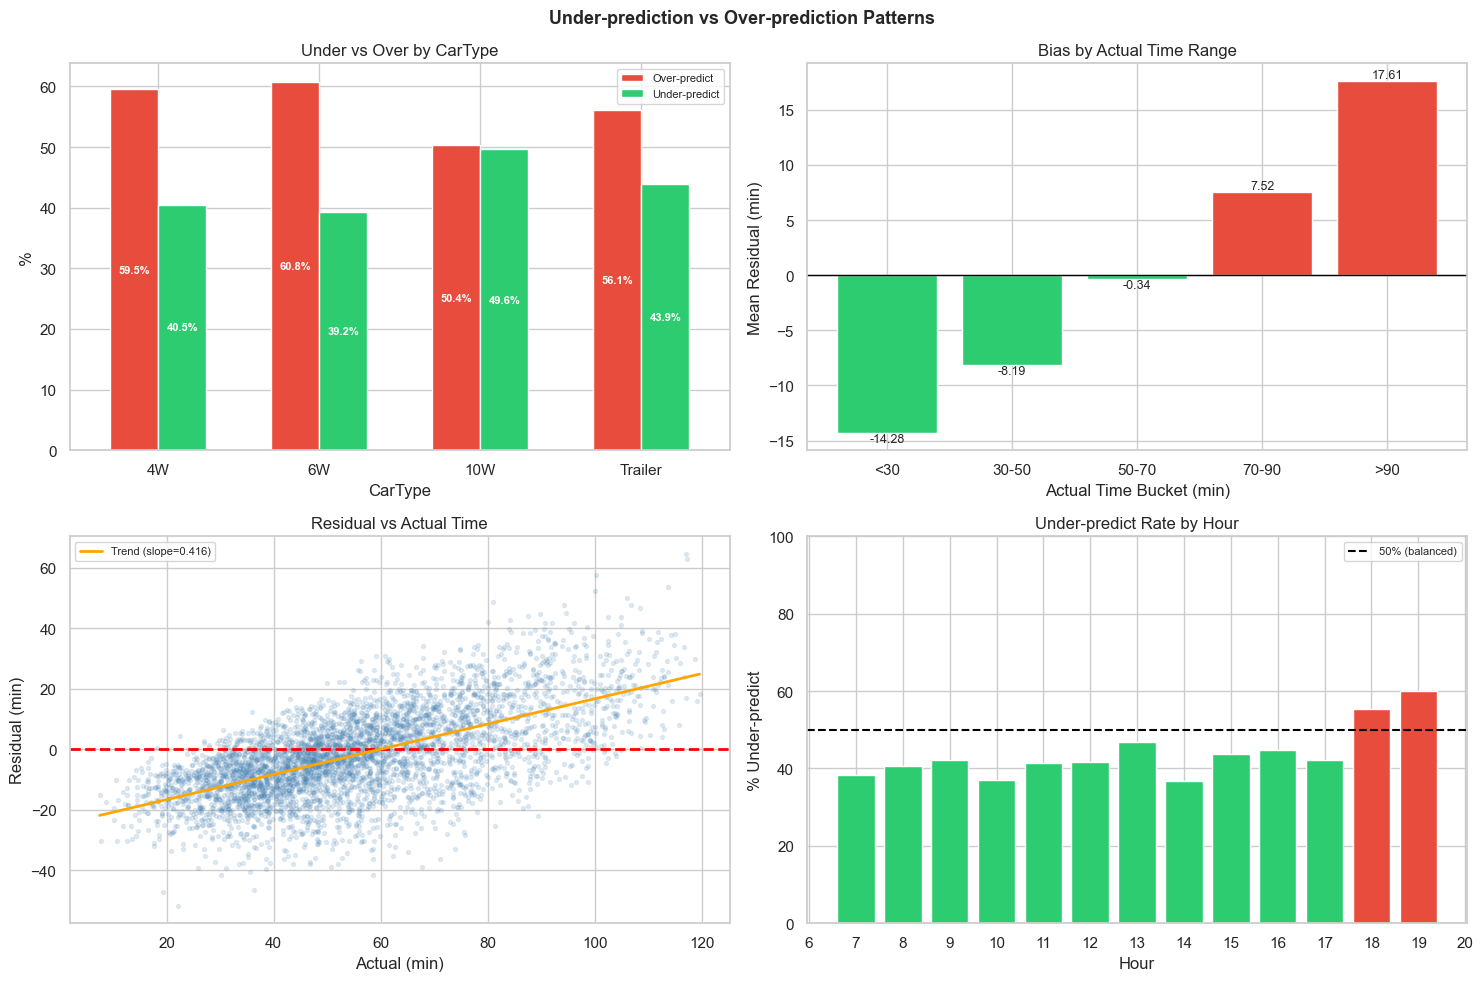

In [11]:
under = err_df[err_df['direction'] == 'Under-predict']
over  = err_df[err_df['direction'] == 'Over-predict']

print(f'Under-predict (actual > predicted) : {len(under):,}  ({len(under)/len(err_df)*100:.1f}%)')
print(f'Over-predict  (actual < predicted) : {len(over):,}  ({len(over)/len(err_df)*100:.1f}%)')
print()
print(f'Under-predict — Mean error  : +{under["abs_error"].mean():.2f} min')
print(f'Over-predict  — Mean error  : -{over["abs_error"].mean():.2f} min')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Under-prediction vs Over-prediction Patterns', fontsize=13, fontweight='bold')

# Under vs over by CarType (stacked %)
ax = axes[0][0]
dir_ct = err_df.groupby(['CarType_lbl', 'direction']).size().unstack(fill_value=0)
dir_ct_pct = dir_ct.div(dir_ct.sum(axis=1), axis=0) * 100
dir_ct_pct = dir_ct_pct.reindex(['4W', '6W', '10W', 'Trailer'])
dir_ct_pct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.6)
ax.set_xlabel('CarType'); ax.set_ylabel('%'); ax.set_title('Under vs Over by CarType')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
for p in ax.patches:
    if p.get_height() > 3:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()/2),
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Residual by actual time bucket
ax = axes[0][1]
err_df['actual_bucket'] = pd.cut(err_df[TARGET],
    bins=[0, 30, 50, 70, 90, np.inf],
    labels=['<30', '30-50', '50-70', '70-90', '>90'])
ab_bias = err_df.groupby('actual_bucket', observed=True)['residual'].mean()
colors_ab = ['#e74c3c' if v > 0 else '#2ecc71' for v in ab_bias]
bars = ax.bar(ab_bias.index.astype(str), ab_bias, color=colors_ab, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', fontsize=9)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('Actual Time Bucket (min)')
ax.set_ylabel('Mean Residual (min)')
ax.set_title('Bias by Actual Time Range')

# Residual vs actual scatter with regression lines
ax = axes[1][0]
ax.scatter(err_df[TARGET], err_df['residual'], alpha=0.15, s=8, color='steelblue')
ax.axhline(0, color='red', lw=2, ls='--')
z = np.polyfit(err_df[TARGET], err_df['residual'], 1)
p = np.poly1d(z)
x_line = np.linspace(err_df[TARGET].min(), err_df[TARGET].max(), 100)
ax.plot(x_line, p(x_line), 'orange', lw=2, label=f'Trend (slope={z[0]:.3f})')
ax.set_xlabel('Actual (min)'); ax.set_ylabel('Residual (min)')
ax.set_title('Residual vs Actual Time')
ax.legend(fontsize=8)

# % under-predict by hour
ax = axes[1][1]
under_pct_hr = err_df.groupby('hour').apply(
    lambda x: (x['direction'] == 'Under-predict').mean() * 100
)
colors_hr = ['#e74c3c' if v > 50 else '#2ecc71' for v in under_pct_hr]
ax.bar(under_pct_hr.index, under_pct_hr, color=colors_hr, edgecolor='white')
ax.axhline(50, color='black', lw=1.5, ls='--', label='50% (balanced)')
ax.set_xlabel('Hour'); ax.set_ylabel('% Under-predict')
ax.set_title('Under-predict Rate by Hour')
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_08_under_over_prediction.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Worst Predictions Deep Dive

=== Top 50 Worst Predictions ===
 total_time_min  predicted  abs_error   residual  pct_error CarType_lbl PickList_lbl  hour  month  total_sap_amount  total_tile_amount  total_fitting_amount  queue_waiting  total_queue
         117.12  52.552666  64.567334  64.567334      55.13     Trailer      Forward     7      2            1971.0             1850.0                 121.0              7            8
         117.30  54.390663  62.909337  62.909337      53.63     Trailer       Normal     8      4            2500.0             2500.0                   0.0              0            7
         100.28  42.576019  57.703981  57.703981      57.54     Trailer       Return    10      2              93.0               50.0                  43.0              1            4
         113.72  60.076927  53.643073  53.643073      47.17     Trailer       Return    12      2            3013.0             2691.0                   5.0              0            3
         100.13  47.662056  52.467944  52.

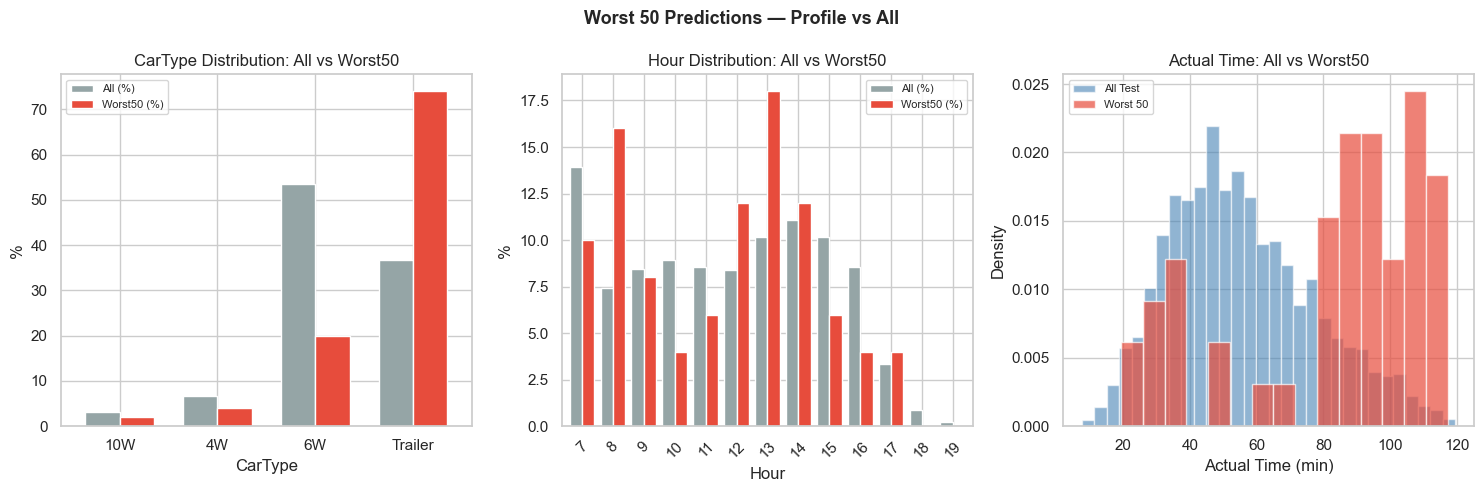

In [12]:
worst_50 = err_df.nlargest(50, 'abs_error').copy()

display_cols = [
    TARGET, 'predicted', 'abs_error', 'residual', 'pct_error',
    'CarType_lbl', 'PickList_lbl', 'hour', 'month',
    'total_sap_amount', 'total_tile_amount', 'total_fitting_amount',
    'queue_waiting', 'total_queue',
]
display_cols = [c for c in display_cols if c in worst_50.columns]

print('=== Top 50 Worst Predictions ===')
print(worst_50[display_cols].sort_values('abs_error', ascending=False).to_string(index=False))

# Profile of worst 50 vs all
print('\n=== Profile: Worst 50 vs All Test Data ===')
profile_cols = ['total_sap_amount', 'total_tile_amount', 'total_fitting_amount',
                'queue_waiting', 'total_queue', TARGET]
profile_cols = [c for c in profile_cols if c in err_df.columns]
comp = pd.DataFrame({
    'All Test (mean)': err_df[profile_cols].mean(),
    'Worst 50 (mean)': worst_50[profile_cols].mean(),
}).round(2)
comp['Ratio'] = (comp['Worst 50 (mean)'] / comp['All Test (mean)']).round(2)
print(comp.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Worst 50 Predictions — Profile vs All', fontsize=13, fontweight='bold')

# CarType distribution
ax = axes[0]
ct_all   = err_df['CarType_lbl'].value_counts(normalize=True) * 100
ct_worst = worst_50['CarType_lbl'].value_counts(normalize=True) * 100
ct_cmp   = pd.DataFrame({'All (%)': ct_all, 'Worst50 (%)': ct_worst}).fillna(0)
ct_cmp.plot(kind='bar', ax=ax, color=['#95a5a6', '#e74c3c'], edgecolor='white', width=0.7)
ax.set_title('CarType Distribution: All vs Worst50')
ax.set_xlabel('CarType'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)

# Hour distribution
ax = axes[1]
hr_all   = err_df['hour'].value_counts(normalize=True).sort_index() * 100
hr_worst = worst_50['hour'].value_counts(normalize=True).sort_index() * 100
hr_cmp   = pd.DataFrame({'All (%)': hr_all, 'Worst50 (%)': hr_worst}).fillna(0)
hr_cmp.plot(kind='bar', ax=ax, color=['#95a5a6', '#e74c3c'], edgecolor='white', width=0.8)
ax.set_title('Hour Distribution: All vs Worst50')
ax.set_xlabel('Hour'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

# Actual time distribution
ax = axes[2]
ax.hist(err_df[TARGET], bins=30, alpha=0.6, color='steelblue', label='All Test', density=True)
ax.hist(worst_50[TARGET], bins=15, alpha=0.7, color='#e74c3c', label='Worst 50', density=True)
ax.set_xlabel('Actual Time (min)'); ax.set_ylabel('Density')
ax.set_title('Actual Time: All vs Worst50')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'ea_09_worst_predictions_profile.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Summary & Recommendations

In [13]:
print('=' * 65)
print('  ERROR ANALYSIS SUMMARY — XGBoost (Optuna)')
print('=' * 65)
print(f'  Test samples  : {len(err_df):,}')
print(f'  MAE           : {mae:.2f} min')
print(f'  RMSE          : {rmse:.2f} min')
print(f'  R²            : {r2:.3f}')
print(f'  Model bias    : {err_df["residual"].mean():.4f} min (near-zero = good)')
print()

bkt = err_df['err_bucket'].value_counts().reindex(
    ['0-5 min','5-10 min','10-15 min','15-30 min','>30 min'])
bkt_pct = (bkt / len(err_df) * 100).round(1)
print('  Error Buckets:')
for lbl, pct in bkt_pct.items():
    print(f'    {lbl:<12}: {pct:.1f}%')

print()
print('  Best performing segments (MAE):')
best_ct = ct_stats['MAE'].idxmin()
print(f'    CarType  : {best_ct}  (MAE={ct_stats.loc[best_ct,"MAE"]:.2f} min)')

best_hr = hr_stats['MAE'].idxmin()
print(f'    Hour     : {best_hr}:00  (MAE={hr_stats.loc[best_hr,"MAE"]:.2f} min)')

print()
print('  Worst performing segments (MAE):')
worst_ct = ct_stats['MAE'].idxmax()
print(f'    CarType  : {worst_ct}  (MAE={ct_stats.loc[worst_ct,"MAE"]:.2f} min)')

worst_hr = hr_stats['MAE'].idxmax()
print(f'    Hour     : {worst_hr}:00  (MAE={hr_stats.loc[worst_hr,"MAE"]:.2f} min)')

worst_sap = sap_stats['MAE'].idxmax()
print(f'    SAP Vol  : {worst_sap}  (MAE={sap_stats.loc[worst_sap,"MAE"]:.2f} min)')

print()
slope = np.polyfit(err_df[TARGET], err_df['residual'], 1)[0]
print('  Key findings:')
if abs(slope) > 0.05:
    direction = 'under-predicts long jobs / over-predicts short jobs' if slope > 0 \
                else 'over-predicts long jobs / under-predicts short jobs'
    print(f'    ⚠ Residual trend detected (slope={slope:.3f}) — model tends to {direction}')
else:
    print(f'    ✓ Residual trend is near-flat (slope={slope:.3f})')

under_rate = (err_df['direction'] == 'Under-predict').mean() * 100
print(f'    Under-predict rate: {under_rate:.1f}%  |  Over-predict rate: {100-under_rate:.1f}%')

print()
print('  Recommendations:')
print('    1. Investigate high-error CarType/Hour combinations (see heatmap)')
print('    2. Large SAP volume jobs (>100) have higher error — consider separate model')
print('    3. Add features: weather/traffic, dock congestion, driver experience')
print('    4. Monitor model on new months — currently trained on Feb-May only')
print('=' * 65)
print()
print('  Figures saved → reports/figures/ea_01 to ea_09')

  ERROR ANALYSIS SUMMARY — XGBoost (Optuna)
  Test samples  : 4,417
  MAE           : 11.43 min
  RMSE          : 14.47 min
  R²            : 0.555
  Model bias    : -1.7641 min (near-zero = good)

  Error Buckets:
    0-5 min     : 27.6%
    5-10 min    : 24.6%
    10-15 min   : 19.0%
    15-30 min   : 24.7%
    >30 min     : 4.1%

  Best performing segments (MAE):
    CarType  : 4W  (MAE=8.79 min)
    Hour     : 15:00  (MAE=10.49 min)

  Worst performing segments (MAE):
    CarType  : Trailer  (MAE=13.98 min)
    Hour     : 18:00  (MAE=12.34 min)
    SAP Vol  : 0-20  (MAE=11.68 min)

  Key findings:
    ⚠ Residual trend detected (slope=0.416) — model tends to under-predicts long jobs / over-predicts short jobs
    Under-predict rate: 41.4%  |  Over-predict rate: 58.6%

  Recommendations:
    1. Investigate high-error CarType/Hour combinations (see heatmap)
    2. Large SAP volume jobs (>100) have higher error — consider separate model
    3. Add features: weather/traffic, dock conges